# Fig 1

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import scipy.io
import pandas as pd
import os

save_dir = '/home/nuttidalab/Documents/spikeRNN/notebooks/CoSyne/figs/'

### 1A: RNN, converting rate -> spiking

### 1B: Task, showing delay periods

In [2]:
normalize_ipscs = 1 # usually will be 1
lesion_connections = 0 # if not lesioning put 0, else 'ii' etc
longer_delay = '' # '' if standard delay (150), longer can be 200 or 250

models_types = ['good_models','bad_models']
norm_name = ['' if normalize_ipscs == 1 else '_raw']
lesion_name = ['' if lesion_connections == 0 else f'_lesion{lesion_connections}']
delay_name = ['' if longer_delay == '' else f'_delay{longer_delay}'][0]

freqbands_list = ['theta','alpha','beta','gamma1','gamma2']

In [4]:
# load a model to get trial times
for models_type in models_types:
    # load list of models
    models_dir = '/home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/' # dir where all models are located
    model_list_path = f'{models_dir}{models_type}/{models_type}_list.mat' # list (saved from matlab) of models of interest
    model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
    model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]
    n_models = len(model_list)
    print(f'Total: {n_models} {models_type} models')

    for n_model, model_fname in enumerate(model_list):
        
        print(f'Loading model {n_model+1}/{n_models}...')
        model_dir = os.path.join(models_dir, model_fname[:model_fname.rfind('.')]) # dir for this model
        
        break
    break

Total: 41 good_models models
Loading model 1/41...


In [6]:
# get necessary trial timing info 

ipsc_savename = f'IPSCs_50travg{norm_name[0]}{lesion_name[0]}{longer_delay}.mat'
ipsc_data = scipy.io.loadmat(os.path.join(model_dir, ipsc_savename)) # load IPSC data ***
T = ipsc_data['T'][0][0]
stim_on = ipsc_data['stim_on'][0][0]
stim_dur = ipsc_data['stim_dur'][0][0]
delay = ipsc_data['delay'][0][0]
fs_rate = 200
fs_spk = 20000
del ipsc_data

# get trial times in real time (s)
T = T/fs_rate
stim_on_time = stim_on/fs_rate
stim_dur_time = stim_dur/fs_rate
delay_time = delay/fs_rate
stim1_on = stim_on_time
stim1_off = stim_on_time + stim_dur_time
stim2_on = stim_on_time + stim_dur_time + delay_time
stim2_off = stim_on_time + 2*stim_dur_time + delay_time

print(f'Trial time: {T} s')
print(f'Stimulus 1: {stim1_on} - {stim1_off} s')
print(f'Stimulus 2: {stim2_on} - {stim2_off} s')
print(f'Delay: {delay_time} s')

Trial time: 2.055 s
Stimulus 1: 0.155 - 0.405 s
Stimulus 2: 1.155 - 1.405 s
Delay: 0.75 s


In [47]:
def plot_stim(T, stim_on, stim_dur, delay):
    # times should be in rate times
    stim1_on = stim_on
    stim1_off = stim_on + stim_dur
    stim2_on = stim_on + stim_dur + delay
    stim2_off = stim_on + 2*stim_dur + delay

    stim = np.zeros(T)
    stim[int(stim1_on):int(stim1_off)] = 1
    stim[int(stim2_on):int(stim2_off)] = 1

    fig, ax = plt.subplots(figsize=(20,2))
    ax.plot(range(T), stim, color='k', linewidth=2)
    # ax.set_xlim([0, T])
    # ax.set_ylim([-1, 1])
    ax.set_yticks([])
    ax.set_xticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    
    # print text above delay
    ax.text(stim1_off + delay/2, 1.1, f'Delay: {delay}ms', ha='center', va='center', fontsize=12)
    # # print text above stim1
    # ax.text(stim1_on + stim_dur/2, 1.3, f'Cue: {stim_dur}ms', ha='center', va='center', fontsize=12)
    # # print text above stim2
    # ax.text(stim2_on + stim_dur/2, 1.3, f'Cue: {stim_dur}ms', ha='center', va='center', fontsize=12)

    plt.savefig(f'{save_dir}1B_delay{delay}.eps', format='eps')

    plt.show()

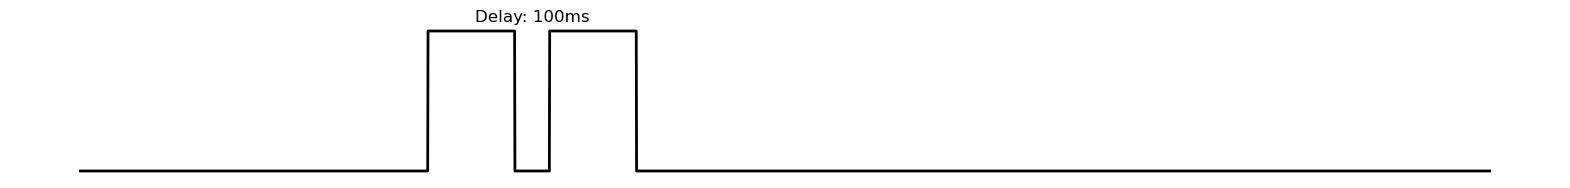

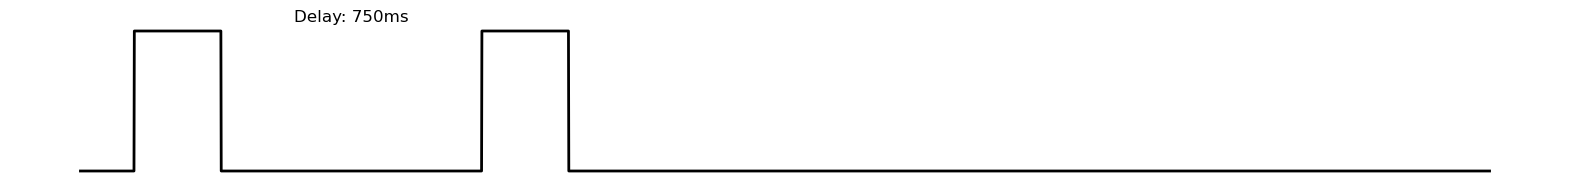

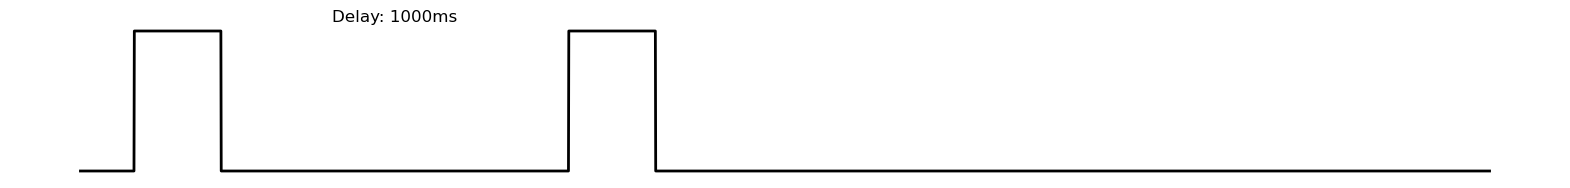

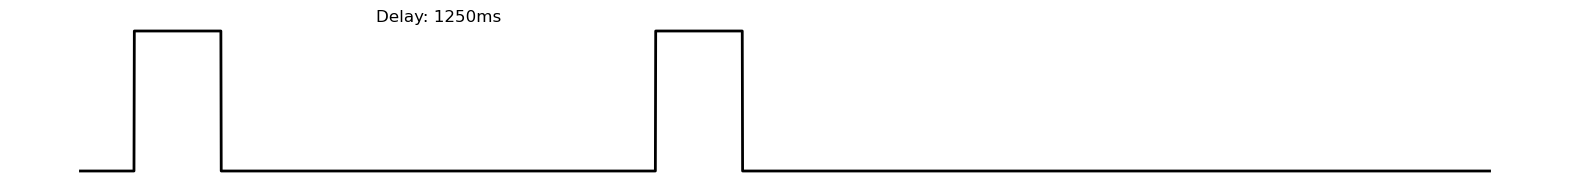

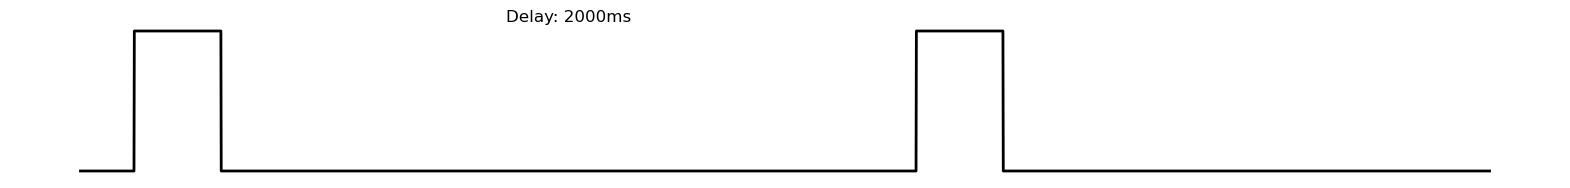

In [48]:
stim_on = [1000, 155, 155, 155, 155]
stim_dur = [250, 250, 250, 250, 250]
delay = [100, 750, 1000, 1250, 2000]
T = [4055, 4055, 4055, 4055, 4055]

for i in range(len(T)):
    plot_stim(T[i], stim_on[i], stim_dur[i], delay[i])

### 1C: No significant differences in synaptic weight btwn good & bad

In [2]:
from scipy.stats import ranksums

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


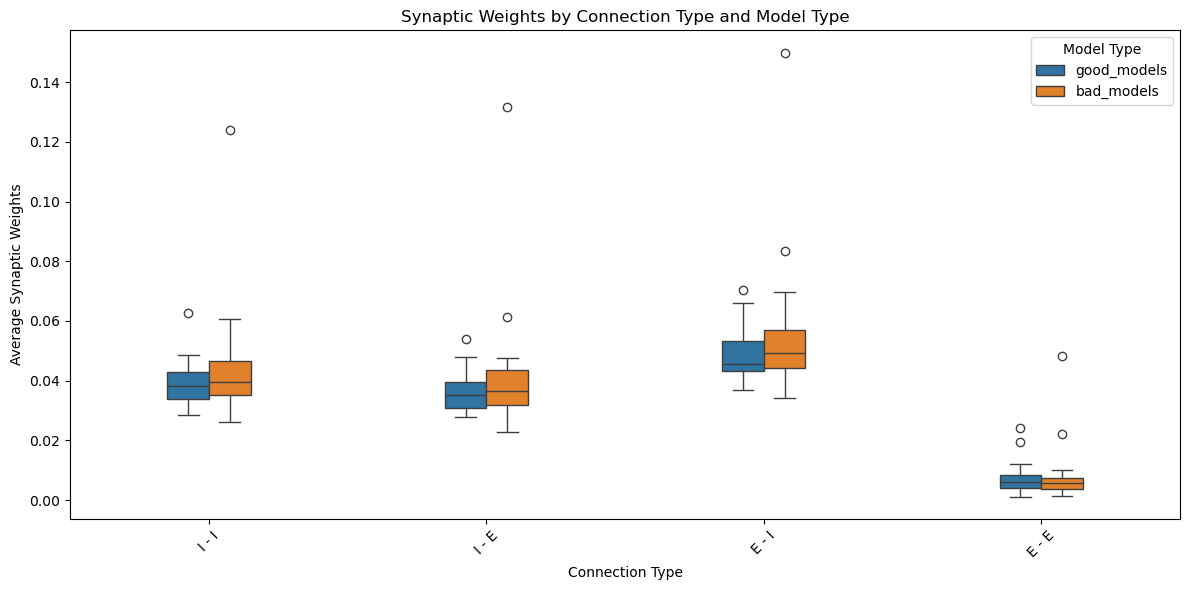

In [3]:
models_types = ['good_models','bad_models']
connection_types_list = ['I - I','I - E','E - I','E - E']
models_dir = '/home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/' # dir where all models are located

# Initialize lists to hold data
all_weights = []
all_model_types = []
all_connection_types = []

# Loop through the model types and gather data
for models_type in models_types:
    mean_synaptic_w = scipy.io.loadmat(f'{models_dir}{models_type}/mean_synaptic_w.mat')['mean_synaptic_w']
    
    # Assuming mean_synaptic_w is structured as (n_models, n_connection_types)
    for connection_idx in range(mean_synaptic_w.shape[1]):
        all_weights.extend(mean_synaptic_w[:, connection_idx])  # Collect weight scores for the connection type
        all_model_types.extend([models_type] * mean_synaptic_w.shape[0])  # Add model type for each score
        all_connection_types.extend([connection_types_list[connection_idx]] * mean_synaptic_w.shape[0])  # Add connection type for each score

# Create a DataFrame for easier plotting
data = pd.DataFrame({
    'Model Type': all_model_types,
    'Connection Types': all_connection_types,
    'Weights': all_weights
})

# Create a grouped boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='Connection Types', y='Weights', hue='Model Type', 
            data=data, width=0.3, dodge=True) 
plt.title('Synaptic Weights by Connection Type and Model Type')
plt.xlabel('Connection Type')
plt.ylabel('Average Synaptic Weights')
plt.legend(title='Model Type')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(f'{save_dir}1C.eps', format='eps')
plt.show()

connection type: I - I, p-value: 0.4250343029017648
connection type: I - E, p-value: 0.45551514959874617
connection type: E - I, p-value: 0.21201557377004432
connection type: E - E, p-value: 0.6995022543981966


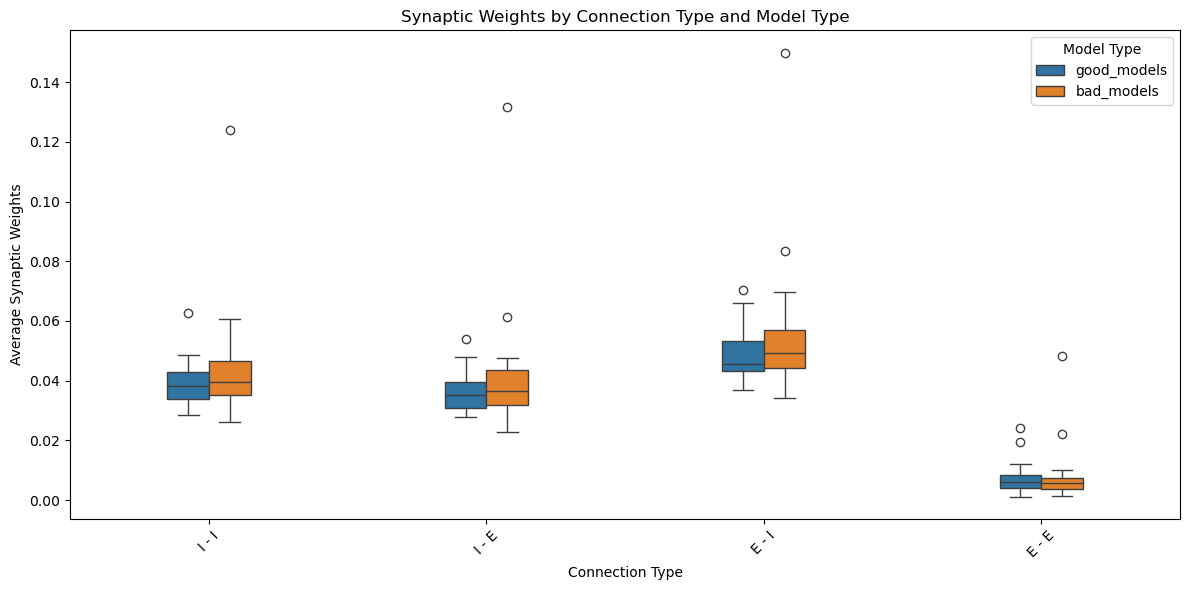

In [5]:
models_types = ['good_models','bad_models']
connection_types_list = ['I - I','I - E','E - I','E - E']
models_dir = '/home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/' # dir where all models are located

# Initialize lists to hold data
all_weights = []
all_model_types = []
all_connection_types = []

# Loop through the model types and gather data
for models_type in models_types:
    mean_synaptic_w = scipy.io.loadmat(f'{models_dir}{models_type}/mean_synaptic_w.mat')['mean_synaptic_w']
    
    # Assuming mean_synaptic_w is structured as (n_models, n_connection_types)
    for connection_idx in range(mean_synaptic_w.shape[1]):
        all_weights.extend(mean_synaptic_w[:, connection_idx])  # Collect weight scores for the connection type
        all_model_types.extend([models_type] * mean_synaptic_w.shape[0])  # Add model type for each score
        all_connection_types.extend([connection_types_list[connection_idx]] * mean_synaptic_w.shape[0])  # Add connection type for each score

# Create a DataFrame for easier plotting
data = pd.DataFrame({
    'Model Type': all_model_types,
    'Connection Types': all_connection_types,
    'Weights': all_weights
})

# Create a grouped boxplot
plt.figure(figsize=(12, 6))
ax = sns.boxplot(x='Connection Types', y='Weights', hue='Model Type', 
                 data=data, width=0.3, dodge=True) 
plt.title('Synaptic Weights by Connection Type and Model Type')
plt.xlabel('Connection Type')
plt.ylabel('Average Synaptic Weights')
plt.legend(title='Model Type', loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()

# Perform the Wilcoxon rank-sum test between model types for each connection type
for connection_type in connection_types_list:
    # Extract weights for the two model types for the current connection type
    group1 = data[(data['Model Type'] == 'good_models') & (data['Connection Types'] == connection_type)]['Weights']
    group2 = data[(data['Model Type'] == 'bad_models') & (data['Connection Types'] == connection_type)]['Weights']
    
    # Perform the rank-sum test only if both groups have data
    if not group1.empty and not group2.empty:
        statistic, p_value = ranksums(group1, group2)
        print('connection type: {}, p-value: {}'.format(connection_type, p_value))

        # Determine significance level for annotation
        if p_value < 0.001:
            significance = '***'
        elif p_value < 0.01:
            significance = '**'
        elif p_value < 0.05:
            significance = '*'
        else:
            significance = ''
        
        # Get the x position for the connection type
        x_pos = connection_types_list.index(connection_type)
        
        # Annotate the significance on the plot
        if significance:
            # Adjust y position for the annotation
            y_pos = max(data['Weights']) + 0.5  # Adjust this based on your data
            ax.annotate(significance, 
                        xy=(x_pos, y_pos), 
                        ha='center', 
                        va='bottom', 
                        fontsize=16, 
                        color='black')


plt.savefig(f'{save_dir}1C_with_significance.eps', format='eps')
plt.show()